In [26]:
pip install pandas numpy matplotlib seaborn openpyxl scipy


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/Users/kaviratna/Desktop/wearable-gait-analysis/data/PAMAP2.xlsx")

df.head()

,subject_id,activity,second_bucket,hand_accel16_x,hand_accel16_y,hand_accel16_z,chest_accel16_x,chest_accel16_y,chest_accel16_z,ankle_accel16_x,ankle_accel16_y,ankle_accel16_z,heart_rate
0,101,ascending_stairs,1551,3.039517,7.267264,5.829460,-0.002165,9.700836,-1.692995,9.780518,-1.107841,-0.985225,123.142857
1,101,ascending_stairs,1552,-0.050928,7.937572,5.115594,-1.141908,9.620771,-1.575923,9.804082,-0.850228,-0.929898,122.700000
2,101,ascending_stairs,1553,-1.422239,8.818402,3.937075,-2.338560,9.493684,-1.399713,9.800257,0.612031,-0.474779,122.000000
3,101,ascending_stairs,1554,-0.394540,7.746597,5.561393,-2.281871,9.438726,-1.758612,9.804589,0.891707,-0.408655,121.444444
4,101,ascending_stairs,1555,-2.468204,7.305927,5.968650,-2.576950,9.356711,-2.055648,9.818612,0.665480,-0.431702,121.000000


In [29]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()
df.describe()
df.isnull().sum()

Rows: 9408
Columns: 13
<class 'pandas.DataFrame'>
RangeIndex: 9408 entries, 0 to 9407
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   subject_id       9408 non-null   int64  
 1   activity         9408 non-null   str    
 2   second_bucket    9408 non-null   int64  
 3   hand_accel16_x   9407 non-null   float64
 4   hand_accel16_y   9407 non-null   float64
 5   hand_accel16_z   9407 non-null   float64
 6   chest_accel16_x  9408 non-null   float64
 7   chest_accel16_y  9408 non-null   float64
 8   chest_accel16_z  9408 non-null   float64
 9   ankle_accel16_x  9408 non-null   float64
 10  ankle_accel16_y  9408 non-null   float64
 11  ankle_accel16_z  9408 non-null   float64
 12  heart_rate       9398 non-null   float64
dtypes: float64(10), int64(2), str(1)
memory usage: 955.6 KB


subject_id          0
activity            0
second_bucket       0
hand_accel16_x      1
hand_accel16_y      1
hand_accel16_z      1
chest_accel16_x     0
chest_accel16_y     0
chest_accel16_z     0
ankle_accel16_x     0
ankle_accel16_y     0
ankle_accel16_z     0
heart_rate         10
dtype: int64

In [30]:
df["activity"].value_counts()

activity
walking              2400
standing             1906
sitting              1861
ascending_stairs     1188
descending_stairs    1064
running               989
Name: count, dtype: int64

In [31]:
activities = [
    "sitting",
    "standing",
    "walking",
    "running",
    "ascending_stairs",
    "descending_stairs"
]

df = df[df["activity"].isin(activities)].copy()

In [32]:
activity_order = [
    "sitting",
    "standing",
    "walking",
    "ascending_stairs",
    "descending_stairs",
    "running"
]

df["activity"] = pd.Categorical(
    df["activity"],
    categories=activity_order,
    ordered=True
)

In [33]:
df["ankle_accel_mag"] = np.sqrt(
    df["ankle_accel16_x"]**2 +
    df["ankle_accel16_y"]**2 +
    df["ankle_accel16_z"]**2
)

df["chest_accel_mag"] = np.sqrt(
    df["chest_accel16_x"]**2 +
    df["chest_accel16_y"]**2 +
    df["chest_accel16_z"]**2
)

df["hand_accel_mag"] = np.sqrt(
    df["hand_accel16_x"]**2 +
    df["hand_accel16_y"]**2 +
    df["hand_accel16_z"]**2
)

In [34]:
accel_summary = (
    df.groupby("activity", observed=True)[
        ["ankle_accel_mag", "chest_accel_mag", "hand_accel_mag"]
    ]
    .mean()
    .reset_index()
)

accel_summary

,activity,ankle_accel_mag,chest_accel_mag,hand_accel_mag
0,sitting,9.950179,9.804579,9.682246
1,standing,9.940095,9.826264,9.703086
2,walking,12.456180,9.881560,10.939091
3,ascending_stairs,10.682707,9.917812,10.286707
4,descending_stairs,11.289168,9.897473,9.667110
5,running,14.892436,9.949855,13.361483


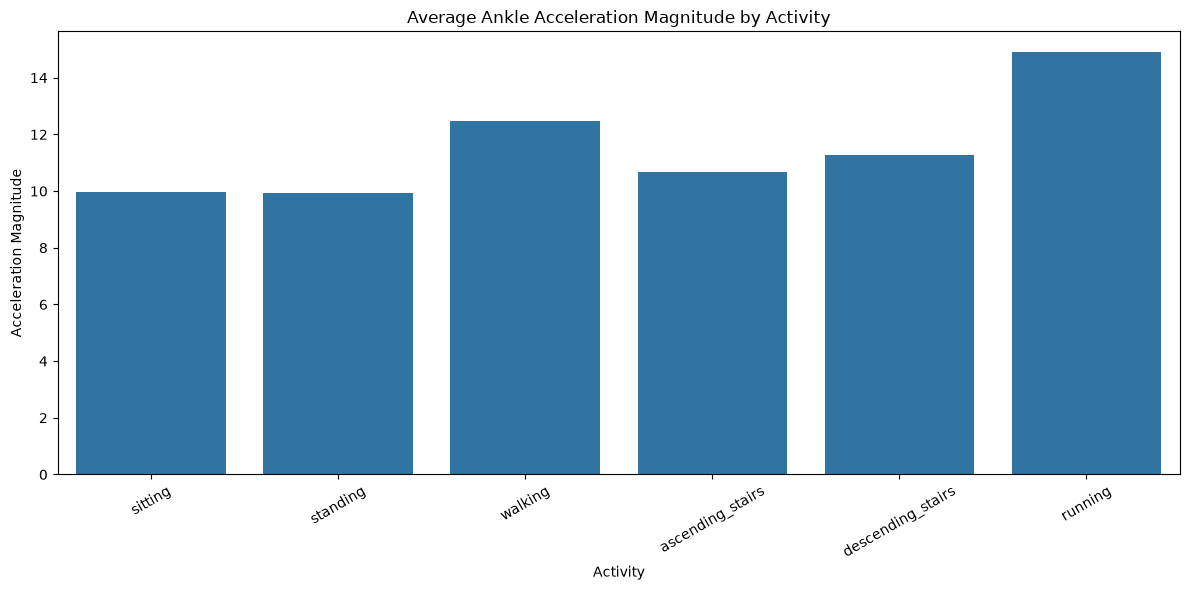

In [35]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=accel_summary,
    x="activity",
    y="ankle_accel_mag"
)

plt.title("Average Ankle Acceleration Magnitude by Activity")
plt.xlabel("Activity")
plt.ylabel("Acceleration Magnitude")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [36]:
df.groupby("activity", observed=True)[
    ["ankle_accel_mag", "chest_accel_mag", "hand_accel_mag"]
].agg(["mean", "std", "min", "max"])

ankle_accel_mag                                 \
                             mean       std       min        max   
activity                                                           
sitting                  9.950179  0.117397  8.979817  10.829622   
standing                 9.940095  0.083944  9.570132  10.958195   
walking                 12.456180  0.874634  9.581249  14.557870   
ascending_stairs        10.682707  1.149786  8.124954  15.911589   
descending_stairs       11.289168  1.305475  8.763637  17.569949   
running                 14.892436  2.139956  9.251142  33.059147   

                  chest_accel_mag                                 \
                             mean       std       min        max   
activity                                                           
sitting                  9.804579  0.123587  8.215550  10.786313   
standing                 9.826264  0.092233  8.995554  10.354546   
walking                  9.881560  0.285567  8.980056  10.907386   
ascending_stairs         9.917812  0.501740  8.417787  11.435190   
descending_stairs        9.897473  0.474631  8.182493  11.493144   
running                  9.949855  1.074830  7.905249  12.296863   

                  hand_accel_mag                                 
                            mean       std       min        max  
activity                                                         
sitting                 9.682246  0.288165  5.422333  10.506329  
standing                9.703086  0.300892  5.242540  10.962411  
walking                10.939091  0.930644  5.590849  15.363860  
ascending_stairs       10.286707  1.163852  5.744054  22.245852  
descending_stairs       9.667110  0.657023  6.453115  12.499120  
running                13.361483  2.922515  7.688055  35.208638

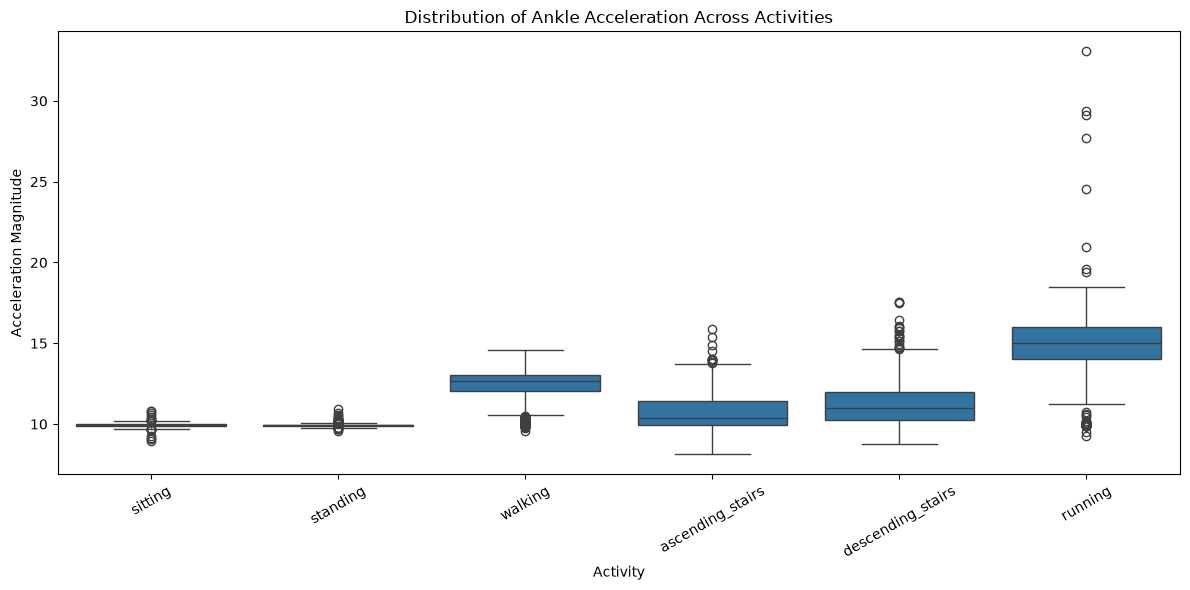

In [37]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="activity",
    y="ankle_accel_mag"
)

plt.title("Distribution of Ankle Acceleration Across Activities")
plt.xlabel("Activity")
plt.ylabel("Acceleration Magnitude")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [38]:
sensor_df = df.melt(
    id_vars=["activity"],
    value_vars=[
        "ankle_accel_mag",
        "chest_accel_mag",
        "hand_accel_mag"
    ],
    var_name="sensor_location",
    value_name="acceleration"
)

In [39]:
sensor_df["sensor_location"] = sensor_df["sensor_location"].replace({
    "ankle_accel_mag": "Ankle",
    "chest_accel_mag": "Chest",
    "hand_accel_mag": "Hand"
})

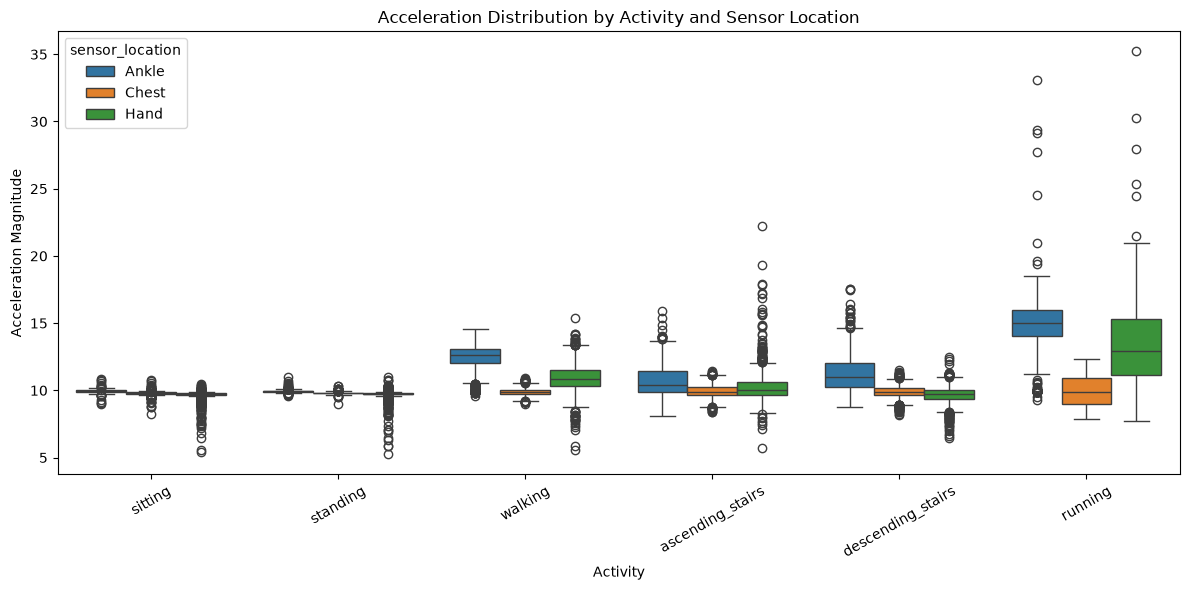

In [40]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=sensor_df,
    x="activity",
    y="acceleration",
    hue="sensor_location"
)

plt.title("Acceleration Distribution by Activity and Sensor Location")
plt.xlabel("Activity")
plt.ylabel("Acceleration Magnitude")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [41]:
hr_summary = (
    df.groupby("activity", observed=True)["heart_rate"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

hr_summary

,activity,mean,std,min,max
0,sitting,80.041522,8.023194,63.000000,113.0
1,standing,88.546214,10.010311,68.222222,112.0
2,walking,112.786178,9.544064,86.000000,128.0
3,ascending_stairs,129.581213,20.987000,71.000000,171.0
4,descending_stairs,129.193644,22.970926,78.000000,175.0
5,running,156.523484,22.882963,81.000000,196.0


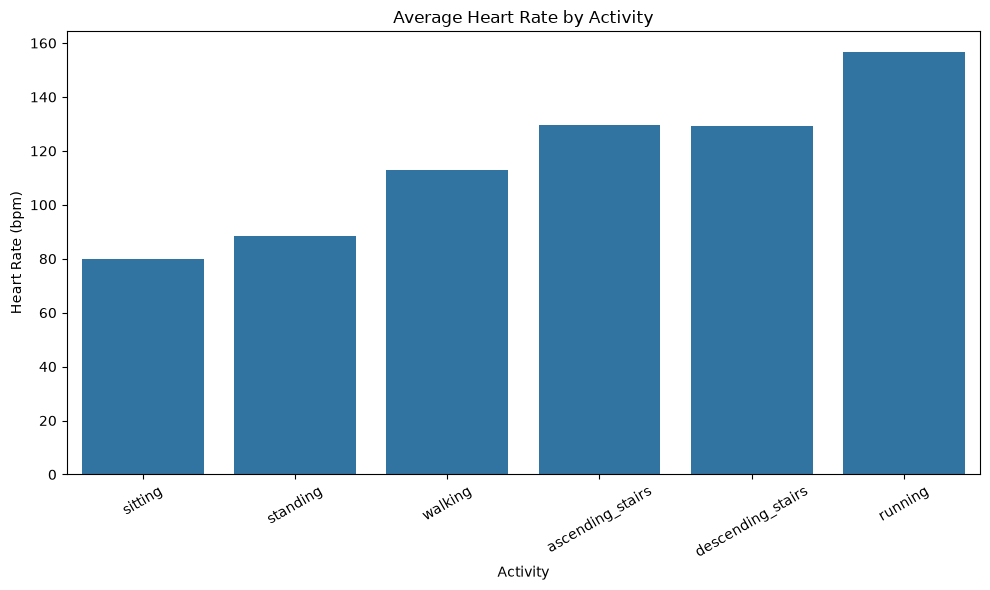

In [42]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=hr_summary,
    x="activity",
    y="mean"
)

plt.title("Average Heart Rate by Activity")
plt.xlabel("Activity")
plt.ylabel("Heart Rate (bpm)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

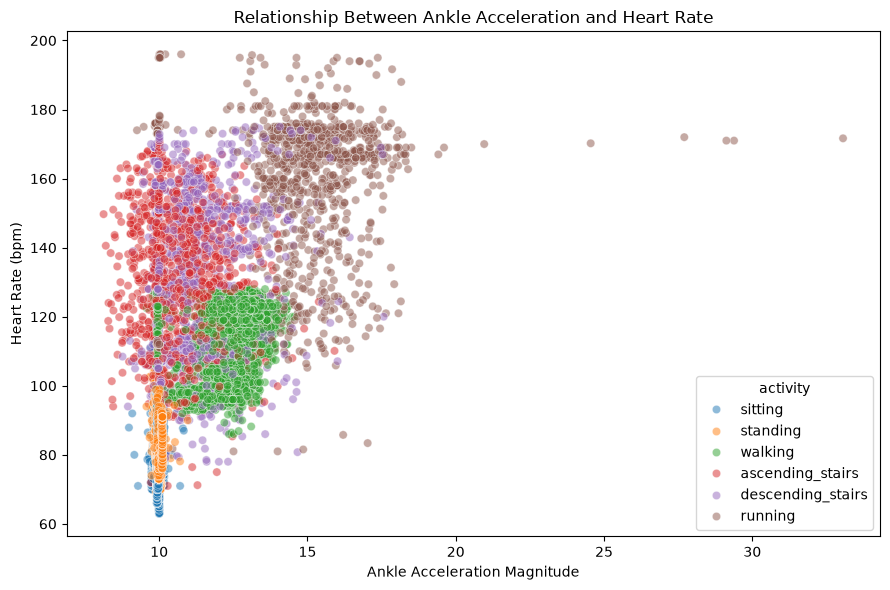

In [43]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="ankle_accel_mag",
    y="heart_rate",
    hue="activity",
    alpha=0.5
)

plt.title("Relationship Between Ankle Acceleration and Heart Rate")
plt.xlabel("Ankle Acceleration Magnitude")
plt.ylabel("Heart Rate (bpm)")

plt.tight_layout()
plt.show()

In [44]:
df[["ankle_accel_mag", "heart_rate"]].corr()

,ankle_accel_mag,heart_rate
ankle_accel_mag,1.000000,0.610357
heart_rate,0.610357,1.000000


In [48]:
# %%
final_summary = (
    df.groupby("activity", observed=True)
    .agg(
        observations=("activity", "size"),
        subjects=("subject_id", "nunique"),

        ankle_accel_mean=("ankle_accel_mag", "mean"),
        ankle_accel_std=("ankle_accel_mag", "std"),

        chest_accel_mean=("chest_accel_mag", "mean"),
        chest_accel_std=("chest_accel_mag", "std"),

        hand_accel_mean=("hand_accel_mag", "mean"),
        hand_accel_std=("hand_accel_mag", "std"),

        heart_rate_mean=("heart_rate", "mean"),
        heart_rate_std=("heart_rate", "std")
    )
    .reset_index()
)

final_summary

,activity,observations,subjects,ankle_accel_mean,ankle_accel_std,chest_accel_mean,chest_accel_std,hand_accel_mean,hand_accel_std,heart_rate_mean,heart_rate_std
0,sitting,1861,8,9.950179,0.117397,9.804579,0.123587,9.682246,0.288165,80.041522,8.023194
1,standing,1906,8,9.940095,0.083944,9.826264,0.092233,9.703086,0.300892,88.546214,10.010311
2,walking,2400,8,12.456180,0.874634,9.881560,0.285567,10.939091,0.930644,112.786178,9.544064
3,ascending_stairs,1188,8,10.682707,1.149786,9.917812,0.501740,10.286707,1.163852,129.581213,20.987000
4,descending_stairs,1064,8,11.289168,1.305475,9.897473,0.474631,9.667110,0.657023,129.193644,22.970926
5,running,989,7,14.892436,2.139956,9.949855,1.074830,13.361483,2.922515,156.523484,22.882963


In [51]:
# %%
final_summary.to_csv(
    "/Users/kaviratna/Desktop/wearable-gait-analysis/outputsv",
    index=False
)
print("Analysis outputs exported successfully.")

Analysis outputs exported successfully.
